In [ ]:
import pandas as pd
df = pd.read_csv("hf://datasets/DominusTea/GreekLegalSum/hugginface_dataset.csv")

# 📊 Exploratory Data Analysis (EDA) of Greek Supreme Court Decisions

---

## 1. Distribution of the Top 15 Case Categories

The dataset is dominated by a few categories, with _"Αιτιολογίας επάρκεια"_ (Sufficiency of Reasoning), _"Ακυρότητα απόλυτη"_ (Absolute Nullity), and _"Αιτιολογίας ανεπάρκεια"_ (Insufficiency of Reasoning) comprising the majority of cases. This reveals that appeals to the Supreme Court focus heavily on procedural or reasoning grounds, confirming legal expectations for the Greek context. The sharp drop-off after the first few categories demonstrates pronounced **class imbalance**: an important consideration for any supervised ML tasks.

---

## 2. Distribution of the Top 15 Case Tags


A similar pattern emerges in the tag distribution. The most frequent tags correspond to procedural or reasoning issues, while a “long tail” of less common tags reflects the diversity and complexity of legal themes. These results further emphasize the **imbalanced, multilabel nature** of the problem.

---

## 3. Distribution of Number of Tags per Decision


Most decisions have 1 to 4 tags, but a significant percentage (about **X%**) feature more than 3. This confirms that the dataset is **truly multilabel**, with substantial overlap among legal themes per decision. This increases both the complexity of the classification task and the richness of potential legal analysis.

---

## 4. Boxplot of Number of Tags per Category (Top 10)


Some categories, like _"Αιτιολογίας επάρκεια"_ and _"Ακυρότητα απόλυτη"_, tend to have more tags per case, an indication that these core procedural issues often co-occur with other legal questions. The presence of outliers (cases with many tags) highlights particularly complex or multifaceted decisions.

---

## 5. Heatmap: Frequency of Top 8 Tags per Top 8 Categories


This heatmap reveals **strong associations** between certain categories and tags (e.g., “Αιτιολογίας επάρκεια” is almost always tagged as such), as well as co-occurrence patterns (some categories, such as “Ακυρότητα απόλυτη”, frequently appear with multiple tags). Such patterns can inform both legal insight and unsupervised learning approaches (e.g., clustering).

---

## 6. Tags with Greatest Category Spread

Some tags, such as _"Αναιρέσεως απαράδεκτο"_ and _"Νόμου εφαρμογή και ερμηνεία"_, appear across many different categories, highlighting their **general legal importance** and broad applicability. Others are more specialized, occurring in only a handful of categories, suggesting domain-specific or rare legal issues.

---

## 7. Pareto Plot for Categories

The Pareto plot starkly illustrates the “long-tail” distribution: a handful of categories account for the vast majority of cases, with the cumulative percentage line leveling off rapidly. This highlights the **statistical challenge** of working with rare classes and underlines the importance of class-balancing strategies.

---

## 8. Violinplot: Tag Count Distribution per Top 6 Categories

Violin plots provide a detailed look at the distribution and outliers for tag counts per major category. Categories such as _"Ακυρότητα απόλυτη"_ display a wider spread, reflecting legal complexity or ambiguity in these cases.

---

## 9. Co-occurrence of Top 10 Tags

The co-occurrence heatmap uncovers which legal themes frequently appear together. These clusters (e.g., “Αιτιολογίας επάρκεια” and “Νόμου εφαρμογή και ερμηνεία”) could inform topic modeling or graph/network analyses, and also reveal practical patterns of legal reasoning.

---

## 10. Boxplot of Summary Length per Category

Certain categories, especially core procedural or reasoning issues, feature longer or more variable summaries, indicating that cases in these areas are more complex or require more detailed justification. This information is relevant for NLP pre-processing and for understanding textual “depth” in different legal areas.

---

## Insights

- The dataset is highly imbalanced, with a few dominant categories and a long tail of rare ones.
- Most cases are multilabel, with significant co-occurrence among legal topics.
- Procedural and reasoning issues (both as categories and tags) dominate the corpus.
- There is substantial variability in both tag count and summary length per category, reflecting the complexity of the legal process at the Supreme Court level.
- The observed patterns have direct implications for downstream modeling: any classifier will need to account for class imbalance and multilabel dependencies, while clustering or topic modeling can leverage the strong co-occurrence structure.

<ipython-input-2-aa6ec9d851a0>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cats.index, x=top_cats.values, palette='crest')


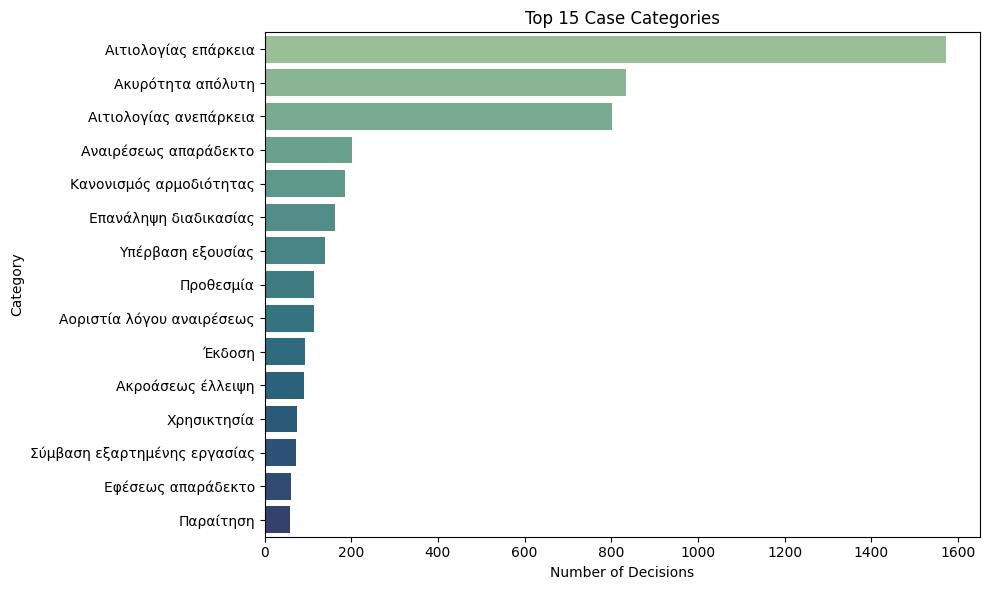

<ipython-input-2-aa6ec9d851a0>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in top_tags], y=[x[0] for x in top_tags], palette='flare')


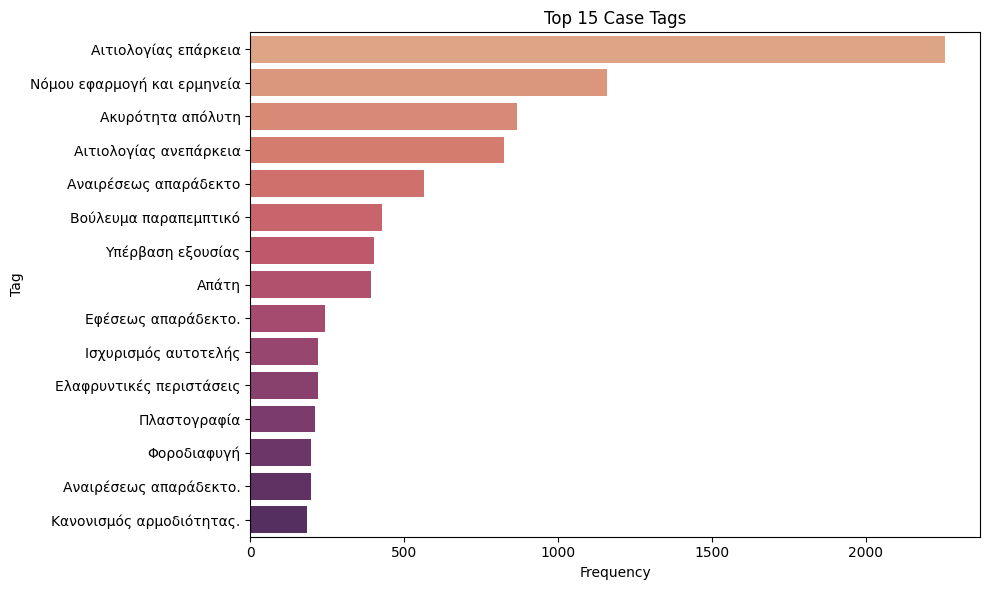

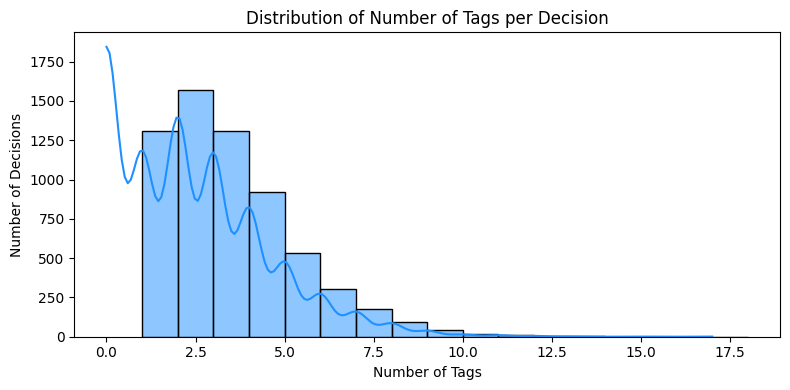

Percentage of decisions with more than 3 tags: 25.1%


<ipython-input-2-aa6ec9d851a0>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['case_category'], x=df['n_tags'], order=cat_order, palette='light:#5A9')


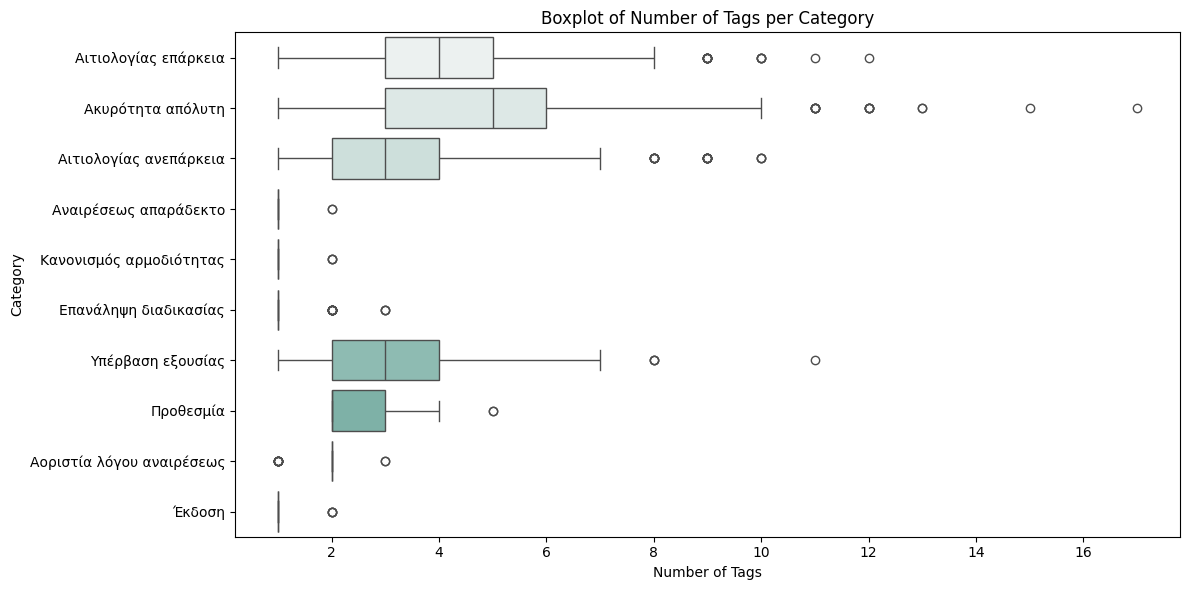

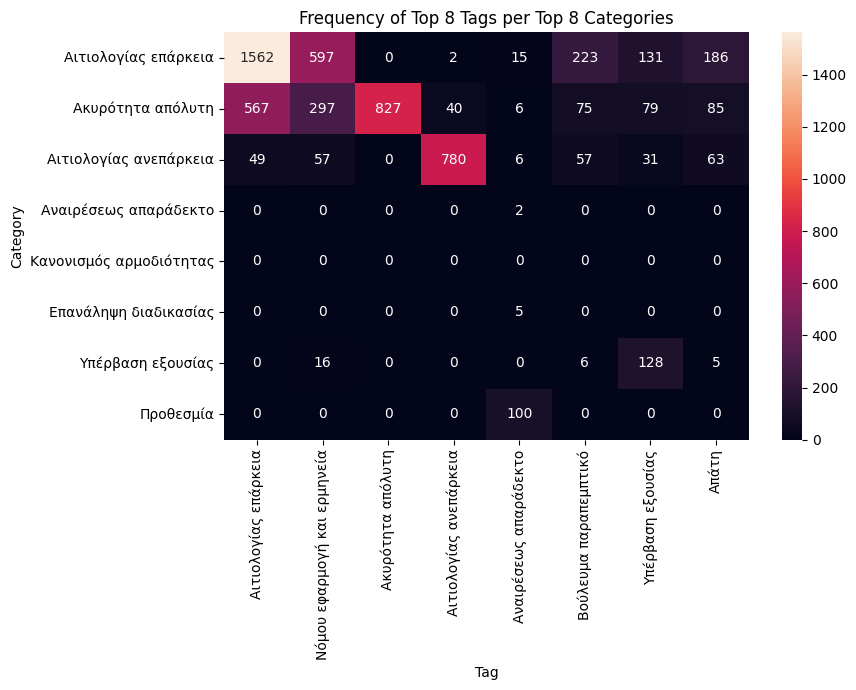

<ipython-input-2-aa6ec9d851a0>:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in diverse_tags], y=[x[0] for x in diverse_tags], palette='cividis')


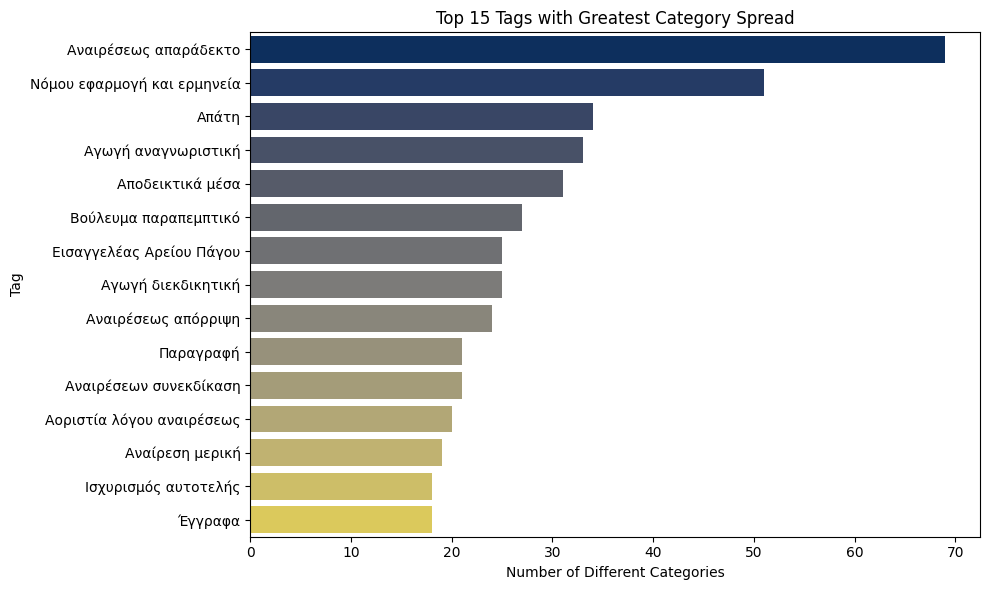

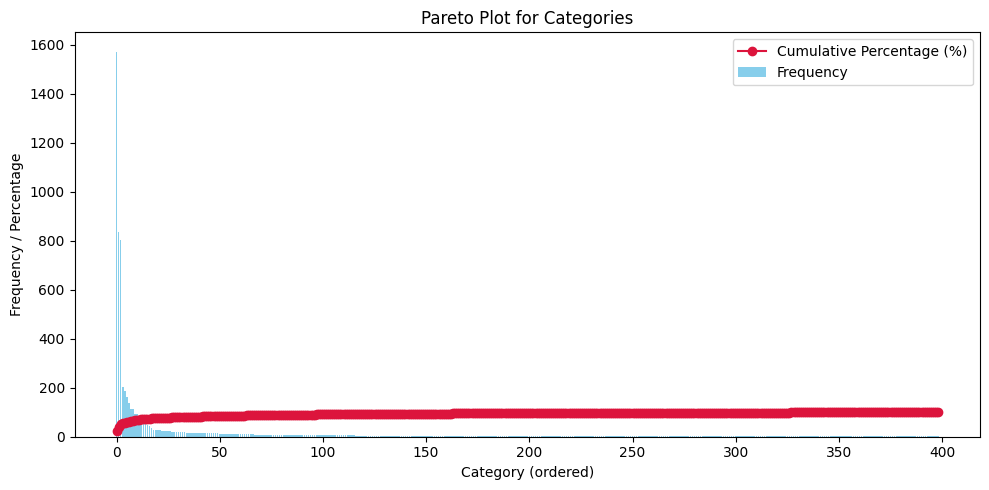

<ipython-input-2-aa6ec9d851a0>:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df['case_category'], x=df['n_tags'], order=top_categories, palette='muted', cut=0)


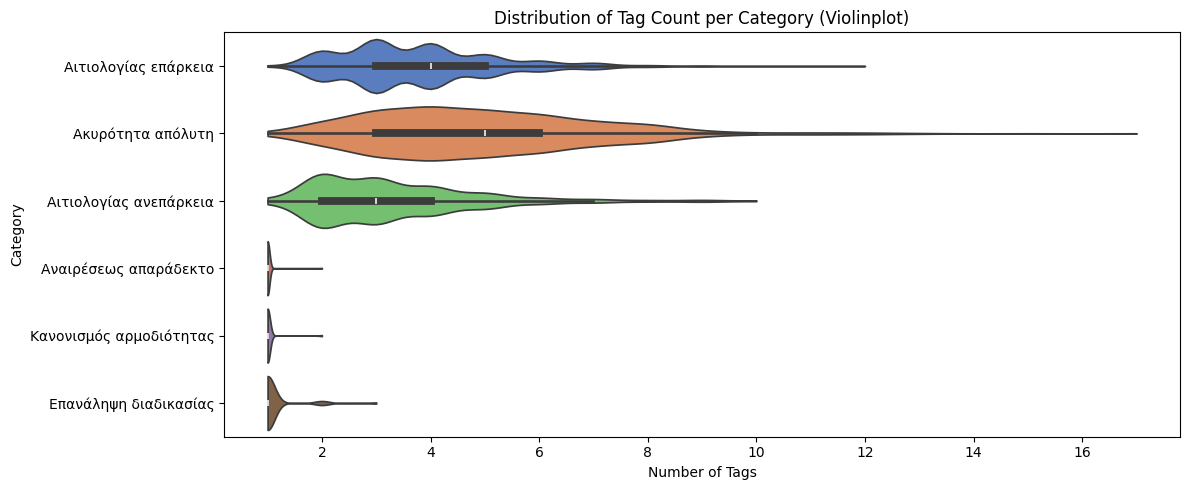

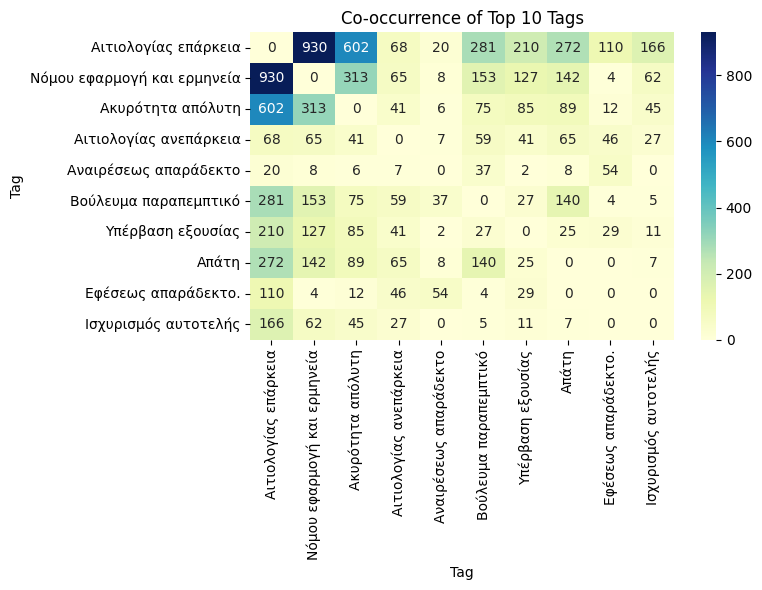

<ipython-input-2-aa6ec9d851a0>:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['case_category'], x=df['summary_len'], order=top_categories, palette='OrRd')


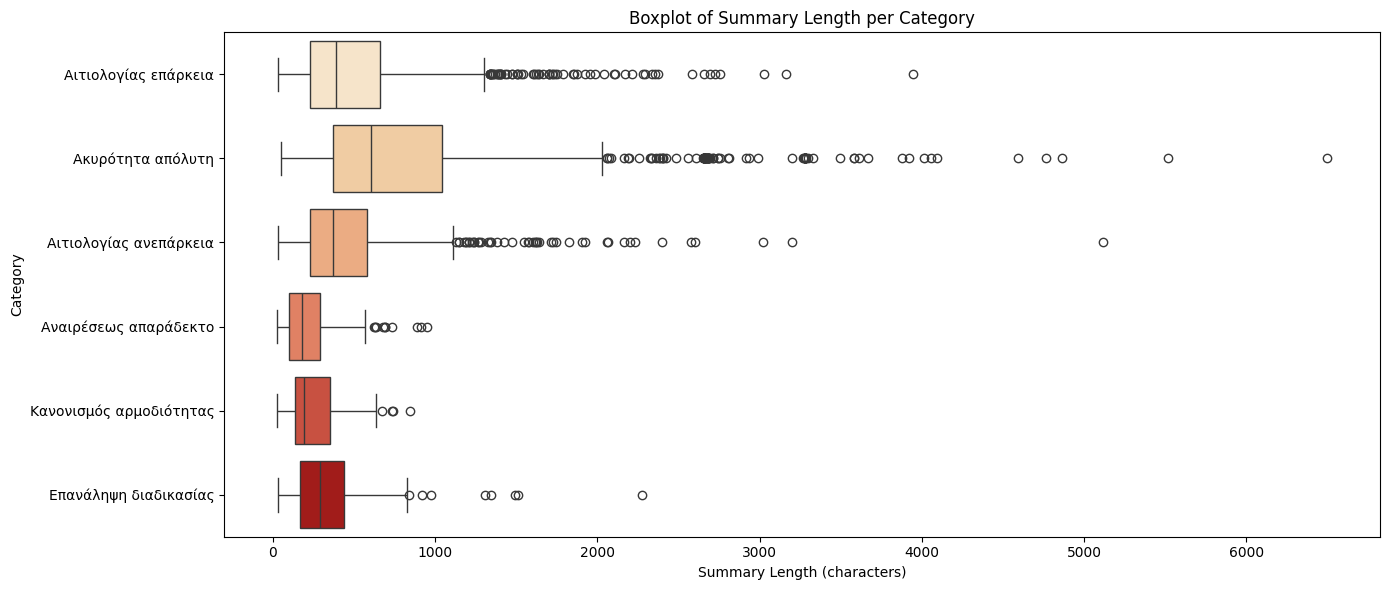

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import chain
import numpy as np
import pandas as pd

# --- Compute columns only if missing ---
if 'n_tags' not in df.columns:
    df['n_tags'] = df['case_tags'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
if 'summary_len' not in df.columns:
    df['summary_len'] = df['summary'].apply(lambda x: len(str(x)))

# ---------------------------------------------------
# 1. Barplot: Top 15 Case Categories
plt.figure(figsize=(10, 6))
top_cats = df['case_category'].value_counts().head(15)
sns.barplot(y=top_cats.index, x=top_cats.values, palette='crest')
plt.title('Top 15 Case Categories')
plt.xlabel('Number of Decisions')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 2. Barplot: Top 15 Case Tags
tags = list(chain.from_iterable(df['case_tags'].dropna().str.split(',')))
tags = [t.strip() for t in tags if t.strip()]
tag_counts = Counter(tags)
top_tags = tag_counts.most_common(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in top_tags], y=[x[0] for x in top_tags], palette='flare')
plt.title('Top 15 Case Tags')
plt.xlabel('Frequency')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 3. Histogram: Number of Tags per Decision
plt.figure(figsize=(8, 4))
sns.histplot(df['n_tags'], bins=range(1, df['n_tags'].max() + 2), color='dodgerblue', kde=True)
plt.title('Distribution of Number of Tags per Decision')
plt.xlabel('Number of Tags')
plt.ylabel('Number of Decisions')
plt.tight_layout()
plt.show()
print("Percentage of decisions with more than 3 tags: {:.1f}%".format((df['n_tags'] > 3).mean()*100))

# ---------------------------------------------------
# 4. Boxplot: Number of Tags per Category (Top 10)
cat_order = df['case_category'].value_counts().index[:10]
plt.figure(figsize=(12, 6))
sns.boxplot(y=df['case_category'], x=df['n_tags'], order=cat_order, palette='light:#5A9')
plt.title('Boxplot of Number of Tags per Category')
plt.xlabel('Number of Tags')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 5. Heatmap: Frequency of Top 8 Tags per Top 8 Categories
top_cats_heat = df['case_category'].value_counts().index[:8]
top_tags_heat = [x[0] for x in tag_counts.most_common(8)]
heatmap_data = pd.DataFrame(0, index=top_cats_heat, columns=top_tags_heat)
for _, row in df.iterrows():
    if row['case_category'] in top_cats_heat and pd.notna(row['case_tags']):
        for tag in row['case_tags'].split(','):
            tag = tag.strip()
            if tag in top_tags_heat:
                heatmap_data.loc[row['case_category'], tag] += 1
plt.figure(figsize=(9, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='rocket')
plt.title('Frequency of Top 8 Tags per Top 8 Categories')
plt.xlabel('Tag')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 6. (Bonus) Barplot: Tags with Greatest Category Spread
tag_to_cats = defaultdict(set)
for _, row in df.iterrows():
    if pd.notna(row['case_tags']) and pd.notna(row['case_category']):
        for tag in row['case_tags'].split(','):
            tag = tag.strip()
            if tag:
                tag_to_cats[tag].add(row['case_category'])
tag_diversity = [(tag, len(cats)) for tag, cats in tag_to_cats.items()]
tag_diversity.sort(key=lambda x: x[1], reverse=True)
diverse_tags = tag_diversity[:15]
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in diverse_tags], y=[x[0] for x in diverse_tags], palette='cividis')
plt.title('Top 15 Tags with Greatest Category Spread')
plt.xlabel('Number of Different Categories')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 7. Pareto Plot for Categories (Cumulative %)
sorted_counts = df['case_category'].value_counts().values
cum_counts = np.cumsum(sorted_counts)
cum_perc = cum_counts / cum_counts[-1] * 100
plt.figure(figsize=(10,5))
plt.bar(range(len(sorted_counts)), sorted_counts, color='skyblue', label='Frequency')
plt.plot(range(len(sorted_counts)), cum_perc, color='crimson', marker='o', label='Cumulative Percentage (%)')
plt.title('Pareto Plot for Categories')
plt.xlabel('Category (ordered)')
plt.ylabel('Frequency / Percentage')
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 8. Violinplot: Tag Count Distribution per Top 6 Categories
top_categories = df['case_category'].value_counts().index[:6]
plt.figure(figsize=(12, 5))
sns.violinplot(y=df['case_category'], x=df['n_tags'], order=top_categories, palette='muted', cut=0)
plt.title('Distribution of Tag Count per Category (Violinplot)')
plt.xlabel('Number of Tags')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 9. Heatmap: Co-occurrence of Top 10 Tags (Tag × Tag)
top_tag_names = [x[0] for x in tag_counts.most_common(10)]
co_matrix = np.zeros((10, 10))
for tags_str in df['case_tags'].dropna():
    tags_here = [tag.strip() for tag in tags_str.split(',') if tag.strip() in top_tag_names]
    for i, tag1 in enumerate(top_tag_names):
        for j, tag2 in enumerate(top_tag_names):
            if tag1 != tag2 and tag1 in tags_here and tag2 in tags_here:
                co_matrix[i, j] += 1
plt.figure(figsize=(8,6))
sns.heatmap(co_matrix, xticklabels=top_tag_names, yticklabels=top_tag_names, annot=True, cmap='YlGnBu', fmt='.0f')
plt.title('Co-occurrence of Top 10 Tags')
plt.xlabel('Tag')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 10. Boxplot: Summary Length per Category (Top 6)
plt.figure(figsize=(14, 6))
sns.boxplot(y=df['case_category'], x=df['summary_len'], order=top_categories, palette='OrRd')
plt.title('Boxplot of Summary Length per Category')
plt.xlabel('Summary Length (characters)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


# K-means Clustering Analysis on Legal Decision Summaries

## 1. Approach & Methodology

We applied K-means clustering to vector representations (embeddings) of legal decision summaries.  
**Pipeline:**
- **Preprocessing:** Filled missing values and processed text summaries.
- **Vectorization:** Used TF-IDF (max 3000 features, no stopwords) to convert each summary into a vector.
- **Clustering:** Ran K-means for a range of clusters \( K \) from 2 to 20.
- **Evaluation:**
    - **Silhouette Score:** Measures how well each sample fits into its assigned cluster.
    - **NMI (Category):** Normalized Mutual Information between cluster assignments and the case category.
    - **NMI (Tags):** NMI between clusters and the main case tag.
- **Visualization:** Plotted scores for each K, and used PCA for 2D cluster visualization.

---

## 2. Evaluation Metrics Across K (Clusters)


**Key:**
- **Silhouette (blue line):** Cluster compactness & separation.
- **NMI (Category, orange):** Cluster alignment with case categories.
- **NMI (Tags, green):** Cluster alignment with main tag.

### Observations:
- All metrics **increase with K**, peaking at the upper range.
- **Silhouette Score** peaks at **K=18**, indicating slightly more distinct clusters at that point.
- **NMI (Category/Tags)** reach their best at **K=20**, suggesting that using more clusters aligns better with the metadata.
- Silhouette values are low (expected for text data), but increasing.

---

## 3. Best K Selection

- **Best K by Silhouette:** **18**
- **Best K by NMI (Category):** **20**
- **Best K by NMI (Tags):** **20**

This shows a trade-off:  
- If **compact and well-separated clusters** are the goal, pick **K=18**.
- If **maximal agreement with category/tag labels** is needed, pick **K=20**.

---

## 4. Cluster Visualization with PCA


- This 2D PCA plot shows the structure of clusters for **K=18**.
- Each color is a cluster.
- Clusters **overlap**, but some distinct groups appear, showing K-means finds some meaningful structure, though boundaries are fuzzy.

---

## 5. Interpretation & Insights

- **Cluster Structure:** Increasing NMI suggests many subtle groupings in the data, which more clusters can capture.
- **Silhouette Score:** Its low but rising trend is typical for text. Even at best K, clusters are not fully separated in embedding space.
- **Visualization:** Confirms partial separation, but not "hard" clusters. Expected for legal text.

---

## 6. Conclusions

- **K-means** reveals underlying structure, especially with higher K.
- **Optimal K** is a trade-off: K=19 by Silhouette, K=20 by NMI.

Fitting K-means: 100%|██████████| 19/19 [01:03<00:00,  3.34s/it]


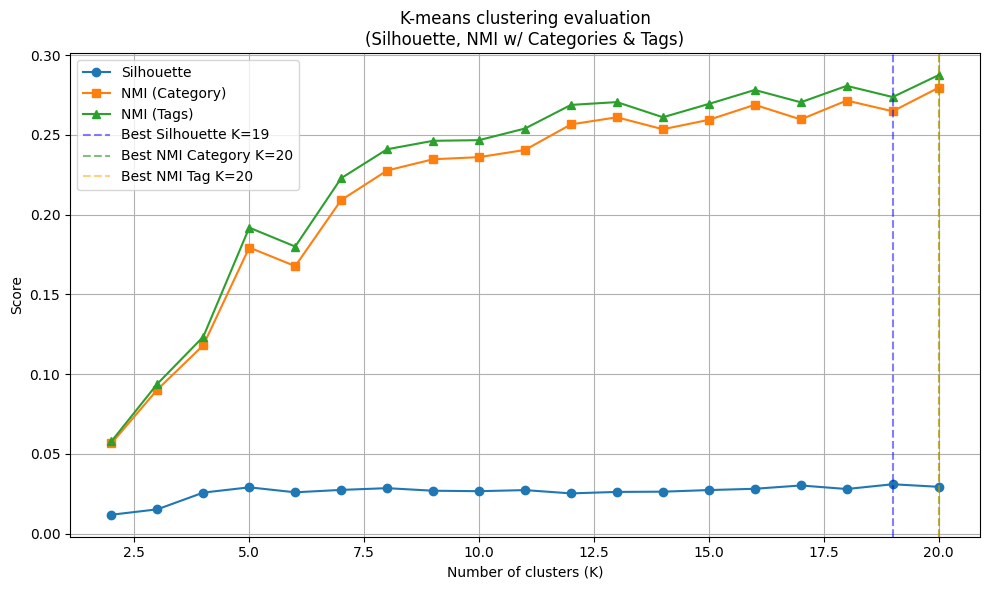

Best K by Silhouette: 19
Best K by NMI (Category): 20
Best K by NMI (Tags): 20


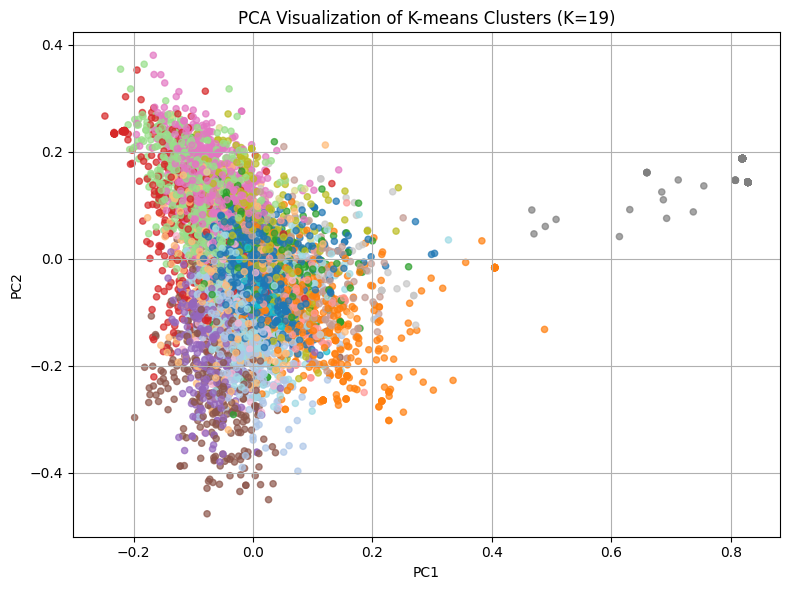

In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# === 1. Data Preparation ===
# Assuming df is already loaded with columns: 'summary', 'case_category', 'case_tags'

# Fill missing values
summaries = df['summary'].fillna('')

# Choose stopwords language depending on your corpus
# For Greek: provide your own list or use a library (e.g., stop_words package)
vectorizer = TfidfVectorizer(max_features=3000, stop_words=None)  # Change to 'greek' or a list if needed
X = vectorizer.fit_transform(summaries)

# === 2. Prepare Ground Truth for NMI ===
# Handle missing categories
case_categories = df['case_category'].fillna('missing')

# For tags, use the first tag (if multiple), or 'missing'
tags_for_nmi = df['case_tags'].fillna('missing').astype(str).apply(
    lambda x: x.split(',')[0].strip() if x else 'missing'
)

# === 3. Run K-means for Multiple K ===
Ks = range(2, 21)
silhouette_scores = []
nmi_category_scores = []
nmi_tags_scores = []

for k in tqdm(Ks, desc="Fitting K-means"):
    # n_init='auto' for sklearn >=1.4, else use n_init=10
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(X)

    # Silhouette Score (higher = better clusters)
    silhouette = silhouette_score(X, labels)
    silhouette_scores.append(silhouette)

    # Normalized Mutual Information (NMI) with categories
    nmi_cat = normalized_mutual_info_score(case_categories, labels, average_method='arithmetic')
    nmi_category_scores.append(nmi_cat)

    # NMI with tags
    nmi_tag = normalized_mutual_info_score(tags_for_nmi, labels, average_method='arithmetic')
    nmi_tags_scores.append(nmi_tag)

# === 4. Visualization & Best K Selection ===

# Find best K for each metric
best_k_sil = Ks[np.argmax(silhouette_scores)]
best_k_nmi_cat = Ks[np.argmax(nmi_category_scores)]
best_k_nmi_tag = Ks[np.argmax(nmi_tags_scores)]

plt.figure(figsize=(10, 6))
plt.plot(Ks, silhouette_scores, marker='o', label='Silhouette')
plt.plot(Ks, nmi_category_scores, marker='s', label='NMI (Category)')
plt.plot(Ks, nmi_tags_scores, marker='^', label='NMI (Tags)')

# Mark best Ks
plt.axvline(best_k_sil, color='blue', linestyle='--', alpha=0.5, label=f'Best Silhouette K={best_k_sil}')
plt.axvline(best_k_nmi_cat, color='green', linestyle='--', alpha=0.5, label=f'Best NMI Category K={best_k_nmi_cat}')
plt.axvline(best_k_nmi_tag, color='orange', linestyle='--', alpha=0.5, label=f'Best NMI Tag K={best_k_nmi_tag}')

plt.xlabel('Number of clusters (K)')
plt.ylabel('Score')
plt.title('K-means clustering evaluation\n(Silhouette, NMI w/ Categories & Tags)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best K by Silhouette: {best_k_sil}")
print(f"Best K by NMI (Category): {best_k_nmi_cat}")
print(f"Best K by NMI (Tags): {best_k_nmi_tag}")

# === 5. (Optional) t-SNE/PCA visualization of clusters for best K ===
from sklearn.decomposition import PCA

best_k = best_k_sil  # or pick based on NMI or visual inspection

kmeans = KMeans(n_clusters=best_k, random_state=0, n_init='auto')
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab20', s=20, alpha=0.7)
plt.title(f'PCA Visualization of K-means Clusters (K={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
# Installs Unsloth, Xformers (Flash Attention) and all other packages!
!pip install unsloth
# Get latest Unsloth
!pip install --upgrade --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-50zi3n19/unsloth_a490dffd43374c8aa21af9b5229b5834
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-50zi3n19/unsloth_a490dffd43374c8aa21af9b5229b5834
  Resolved https://github.com/unslothai/unsloth.git to commit 43514d9d0fbd7b468ddc80b2ea728870b6efd39d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [30]:
from unsloth import FastLanguageModel

# This line downloads and loads the model with Unsloth's optimizations
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "ilsp/Llama-Krikri-8B-Instruct",
    max_seq_length = 8192,
    load_in_4bit = True,
)

==((====))==  Unsloth 2025.5.9: Fast Llama patching. Transformers: 4.52.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [ ]:
from transformers import TextStreamer
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

In [23]:
# --- ALL IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, pairwise_distances

# --- LLM EXTRACTION FUNCTION ---
import re

def extract_llm_theme_chat(summaries, model, tokenizer, max_new_tokens=128, max_length=1000):
    """
    Given a list of legal summaries and an LLM+tokenizer, queries for the cluster theme,
    extracts the theme after 'Θέμα:' or robustly falls back to a valid line.
    """
    texts = [str(s).strip() for s in summaries if s and len(str(s).strip()) > 10]
    if not texts:
        return "NO_SUMMARY"
    combined = "\n\n".join(texts)[:max_length]

    messages = [
        {"role": "system", "content": "Είσαι ένα σύστημα ΤΝ για την ανάλυση νομικών αποφάσεων του Αρείου Πάγου."},
        {"role": "user", "content":
            f"Ποιο είναι το κεντρικό θέμα της απόφασης που ακολουθεί; Απάντησε με μία φράση, ξεκινώντας με 'Θέμα:'.\n"
            f"{combined}"
        }
    ]
    # Tokenize & model call
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )
    if hasattr(inputs, 'items'):
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
    else:
        input_ids = inputs.to(model.device)
        attention_mask = None
    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        use_cache=True
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print("\n==== RAW LLM OUTPUT ====\n", response, "\n=======================\n")

    # --- Try extracting with regex: Θέμα:\s* ... up to empty line, =, or end ---
    theme_pattern = r"Θέμα:\s*([\s\S]*?)(?=\n{2,}|={2,}|$)"
    match = re.search(theme_pattern, response)
    if match:
        theme = match.group(1).strip()
        theme = theme.split('\n')[0].strip()
        if len(theme) > 3 and not theme.lower().startswith(('system', 'cutting')) and not theme.lower().startswith('today date'):
            return theme

    # --- Fallback: Find first valid line after Θέμα: ---
    lines = response.splitlines()
    found = False
    for line in lines:
        line = line.strip()
        if found and line:
            if len(line) > 3 and not line.lower().startswith(('system', 'cutting')) and not line.lower().startswith('today date'):
                if not re.match(r'^\d{1,2}\s+\w+\s+\d{4}', line):  # skip date lines
                    return line
        if "Θέμα:" in line:
            found = True

    # --- Final fallback: Find first line that is not system/date/non-content ---
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.lower().startswith(('system', 'cutting')):
            continue
        if re.match(r'^today date[:：]', line.lower()):
            continue
        if re.match(r'^\d{1,2}\s+\w+\s+\d{4}', line):  # Dates like '26 July 2024'
            continue
        if re.match(r'^={2,}$', line):
            continue
        if len(line) < 4 or not re.search(r'\w', line):
            continue
        return line

    return "NO_THEME"



# --- HELPER FUNCTIONS FOR CLUSTER SAMPLE PICKING ---
def get_random_summaries(df, cluster_id, n=3, seed=42):
    idxs = df[df['cluster'] == cluster_id].index.tolist()
    if len(idxs) < n: return []
    np.random.seed(seed + cluster_id)
    return df.loc[np.random.choice(idxs, n, replace=False), 'summary'].tolist()

def get_centroid_summaries(df, X, cluster_id, kmeans, n=3):
    idxs = df[df['cluster'] == cluster_id].index.tolist()
    if len(idxs) < n: return []
    centroid = kmeans.cluster_centers_[cluster_id]
    cluster_vectors = X[idxs].toarray() if hasattr(X, 'toarray') else X[idxs]
    distances = pairwise_distances(cluster_vectors, centroid.reshape(1, -1)).flatten()
    nearest_idxs = np.array(idxs)[np.argsort(distances)[:n]]
    return df.loc[nearest_idxs, 'summary'].tolist()

# --- TEST ON SINGLE SUMMARY (ALWAYS DO THIS FIRST!) ---
print("Sample LLM theme:", extract_llm_theme_chat([df['summary'].dropna().iloc[0]], model, tokenizer))

# --- COLLECT SAMPLES FOR EACH CLUSTER ---
best_k = 19
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init='auto')
labels = kmeans.fit_predict(X)
df['cluster'] = labels

cluster_titles_random = {}
cluster_titles_centroid = {}

for cluster_id in sorted(df['cluster'].unique()):
    idxs = df[df['cluster'] == cluster_id].index.tolist()
    if len(idxs) < 3:
        continue
    cluster_titles_random[cluster_id] = get_random_summaries(df, cluster_id, n=3)
    cluster_titles_centroid[cluster_id] = get_centroid_summaries(df, X, cluster_id, kmeans, n=3)

# --- EXTRACT LLM THEMES FOR EACH CLUSTER ---
results = []

for cluster_id in cluster_titles_random.keys():
    summaries_random = cluster_titles_random[cluster_id]
    summaries_centroid = cluster_titles_centroid[cluster_id]
    print(f"\n--- Cluster {cluster_id} summaries (random):\n", summaries_random)
    print(f"\n--- Cluster {cluster_id} summaries (centroid):\n", summaries_centroid)

    try:
      title_random = extract_llm_theme_chat(summaries_random, model, tokenizer)
      title_centroid = extract_llm_theme_chat(summaries_centroid, model, tokenizer)


    except Exception as e:
        title_random = f"Error: {e}"
        title_centroid = f"Error: {e}"
    results.append({
        "Cluster": cluster_id,
        "Random Title": title_random,
        "Centroid Title": title_centroid,
        "Num Samples": len(df[df['cluster'] == cluster_id])
    })
    print(f"Cluster {cluster_id} | Random: {title_random} | Centroid: {title_centroid}")

results_df = pd.DataFrame(results)
display(results_df)



==== RAW LLM OUTPUT ====
 system

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

Είσαι ένα σύστημα ΤΝ για την ανάλυση νομικών αποφάσεων του Αρείου Πάγου.user

Ποιο είναι το κεντρικό θέμα της απόφασης που ακολουθεί; Απάντησε με μία φράση, ξεκινώντας με 'Θέμα:'.
Αίτηση αναίρεσης καταδικαστικής αποφάσεως για πλαστογραφία με χρήση και κακουργηματική απάτη κατ’ εξακολούθηση με τη συνδρομή του Ν. 1608/1950 και για ηθική αυτουργία με την επίκληση των λόγων: α) της ελλείψεως ειδικής και εμπεριστατωμένης αιτιολογίας, β) της εσφαλμένης ερμηνείας και εφαρμογής των ουσιαστικών ποινικών διατάξεων, γ) της απόλυτης ακυρότητας. Υπάρχει αιτιολογία, τόσο ως προς την ενοχή, όσο και για τον αυτοτελή ισχυρισμό του άρθρου 84 παρ. 2α του ΠΚ. Συρρέει η χρήση πλαστού εγγράφου με την απάτη κατ’ εξακολούθηση (ΑΠ 965/2006). Απορρίπτει αιτήσεις αναίρεσης.assistant

Θέμα: Απόρριψη αιτήσεων αναίρεσης σε υπόθεση πλαστογραφίας και απάτης με συνδρομή του Ν. 1608/1950. 

Sample LLM theme: Αίτηση αναίρε

,Cluster,Random Title,Centroid Title,Num Samples
0,0,Μη έγκαιρη καταβολή εργοδοτικών εισφορών ΤΑΤΤΑ...,Μη καταβολή χρεών στο Δημόσιο. Αιτιολογία αποφ...,208
1,1,Παραπεμπτικό βούλευμα για σωματεμπορία κατ' επ...,Καταδικαστική απόφαση για κακουργηματική υπεξα...,587
2,2,"Απορρίπτει αίτηση αναίρεσης, ως απαράδεκτη, εφ...",Απορρίπτει ως απαράδεκτη την αίτηση αναίρεσης.,495
3,3,Απόρριψη λόγου αναιρέσεως για έλλειψη επιβαλλό...,Κακουργηματική απάτη. Βούλευμα. Απέρριψε έφεση...,389
4,4,Αίτηση αναιρέσεως εισαχθεί-σα κατά τη διαδικασ...,Άρθρο 473 παρ. 2 εδάφιο Α΄ ΚΠΔ. Αναίρεση με δή...,270
5,5,"Απορρίπτει Αίτηση Αναίρεσης, ως αβάσιμη. Σωματ...",Σωματική βλάβη από αμέλεια. Αναίρεση για ανεπα...,247
6,6,Βάσιμος ο εκ του 510 παρ.1 στοιχ. Δ' του ΚΠΔ λ...,Από κοινού λαθρεμπορία κατ' εξακολούθηση. Πλασ...,670
7,7,Αίτηση επανάληψης της διαδικασίας. Πότε υπάρχο...,Αίτηση επανάληψης διαδικασίας που περατώθηκε μ...,187
8,8,Αίτηση αναίρεσης καταδικαστικής αποφάσεως για ...,Εμπρησμός από αμέλεια. Αναίρεση καταδικαστικής...,253
9,9,"Παράβαση τροφίμων - κρεάτων, ακαταλλήλων προς ...",Αβάσιμοι οι από το άρθρο 510 παρ. 1 στοιχ. Δ κ...,359


<ipython-input-31-634e6a378b4c>:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


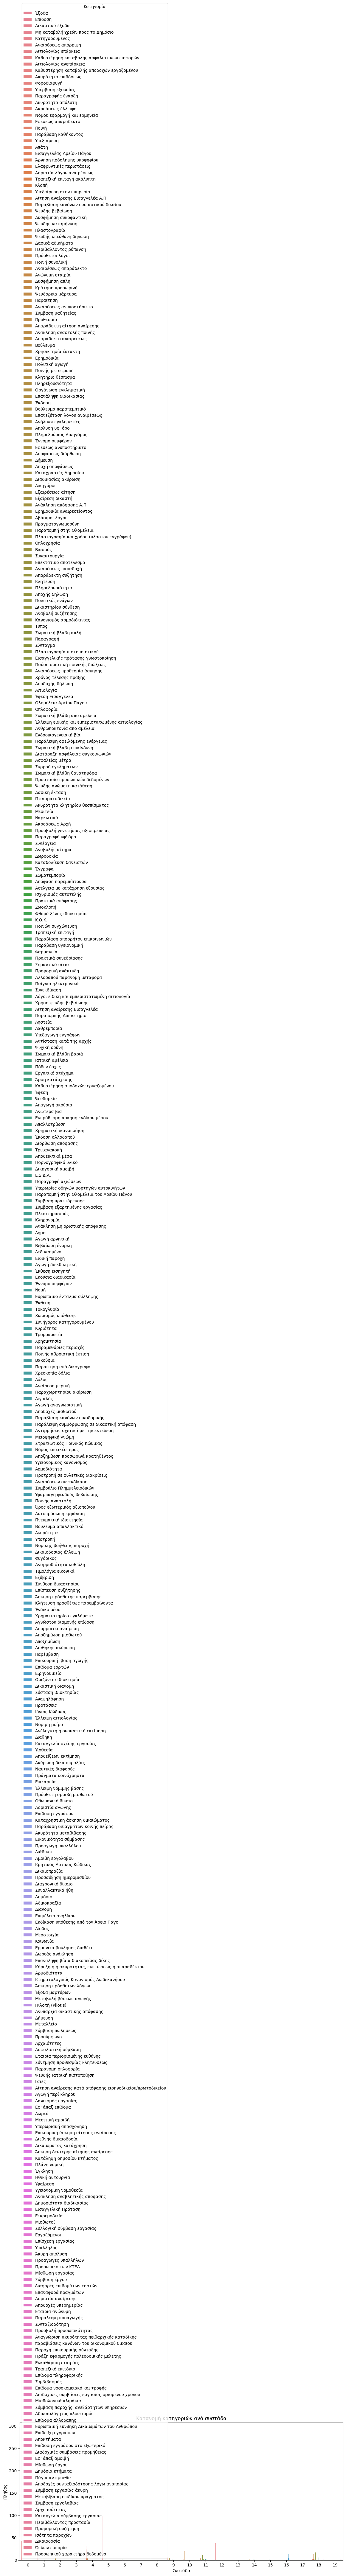

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='cluster', hue='case_category')  # βάλε το σωστό column name για labels!
plt.title('Κατανομή κατηγοριών ανά συστάδα')
plt.xlabel('Συστάδα')
plt.ylabel('Πλήθος')
plt.legend(title='Κατηγορία')
plt.tight_layout()
plt.show()


In [32]:
for cluster_id in results_df['Cluster']:
    print("\n--- Cluster", cluster_id, "---")
    print("Random Title:", results_df.loc[results_df['Cluster']==cluster_id, 'Random Title'].values[0])
    print("Centroid Title:", results_df.loc[results_df['Cluster']==cluster_id, 'Centroid Title'].values[0])
    print("Top labels:")
    print(df[df['cluster']==cluster_id]['case_category'].value_counts(normalize=True).head())



--- Cluster 0 ---
Random Title: Μη έγκαιρη καταβολή εργοδοτικών εισφορών ΤΑΤΤΑ. Παραβάσεις άρθρου 1 παρ. 1 και 2 του Α.Ν. 86/1967. Στοιχεία του αδικήματος. Αιτιολογία του δόλου. Μη αναφορά ιδιότητας κατηγορουμένου στην Α.Ε. Χρόνος που επιδρά στην παραγραφή. Στοιχεία εγκλήματος. Πότε είναι αιτιολογημένη η σχετική απόφαση. Δεν ήταν απαραίτητο να προσδιορίζεται ο αριθμός των μισθωτών, ο χρόνος που εργάστηκε ο καθένας από αυτούς και το ύψος των αποδοχών τους. Αναιρείται η προσβαλλόμενη απόφαση για ελλιπή αιτιολογία. Δεν προκύπτει, η ιδιότητα και η θέση και η εμπλοκή του ενός αναιρεσείοντος - κατηγορούμενου στην ανώνυμη αυτή εταιρεία. Δεν αρκεί η αναφορά ότι αυτός ήταν εργοδότης και νόμιμος εκπρόσωπός της. Επίσης δεν αναφέρεται ο ακριβής χρόνος τέλεσης των επί μέρους πράξεων ο οποίος επί του προκειμένου έχει επιρροή στο ζήτημα της παραγραφής. Αναιρεί και παραπέμπει.
Centroid Title: Μη καταβολή χρεών στο Δημόσιο. Αιτιολογία αποφάσεως. Στοιχεία αδικήματος άρθρου 25 του Ν. 1882/1990, όπως αντ

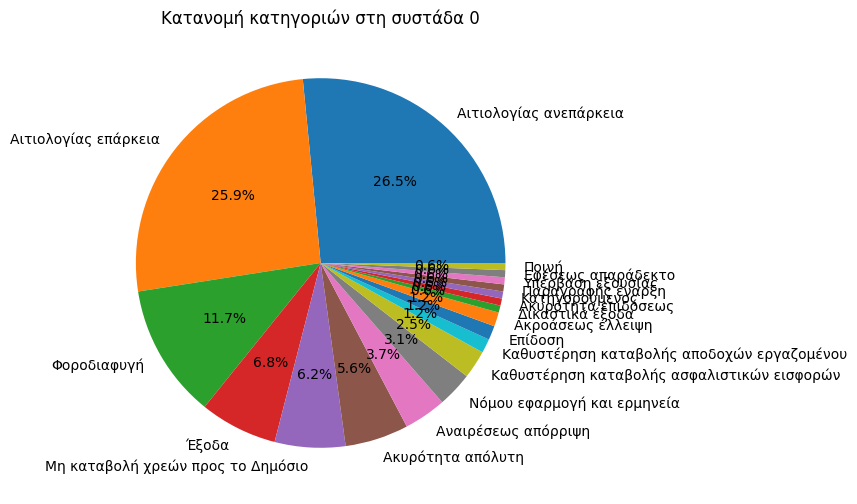

In [33]:
CLUSTER_ID = 0  # Αλλάζεις αριθμό συστάδας
labels = df[df['cluster'] == CLUSTER_ID]['case_category'].value_counts()
labels.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title=f'Κατανομή κατηγοριών στη συστάδα {CLUSTER_ID}')
plt.ylabel('')
plt.show()


In [34]:
for cluster_id in results_df['Cluster'].head(3):  # ή διάλεξε όποιες θες
    print("\n=== Συστάδα", cluster_id, "===")
    print("Random Title:", results_df.loc[results_df['Cluster']==cluster_id, 'Random Title'].values[0])
    print("Centroid Title:", results_df.loc[results_df['Cluster']==cluster_id, 'Centroid Title'].values[0])
    top_labels = df[df['cluster']==cluster_id]['case_category'].value_counts(normalize=True).head(5)
    print("Κορυφαίες κατηγορίες (ποσοστά):")
    print(top_labels)



=== Συστάδα 0 ===
Random Title: Μη έγκαιρη καταβολή εργοδοτικών εισφορών ΤΑΤΤΑ. Παραβάσεις άρθρου 1 παρ. 1 και 2 του Α.Ν. 86/1967. Στοιχεία του αδικήματος. Αιτιολογία του δόλου. Μη αναφορά ιδιότητας κατηγορουμένου στην Α.Ε. Χρόνος που επιδρά στην παραγραφή. Στοιχεία εγκλήματος. Πότε είναι αιτιολογημένη η σχετική απόφαση. Δεν ήταν απαραίτητο να προσδιορίζεται ο αριθμός των μισθωτών, ο χρόνος που εργάστηκε ο καθένας από αυτούς και το ύψος των αποδοχών τους. Αναιρείται η προσβαλλόμενη απόφαση για ελλιπή αιτιολογία. Δεν προκύπτει, η ιδιότητα και η θέση και η εμπλοκή του ενός αναιρεσείοντος - κατηγορούμενου στην ανώνυμη αυτή εταιρεία. Δεν αρκεί η αναφορά ότι αυτός ήταν εργοδότης και νόμιμος εκπρόσωπός της. Επίσης δεν αναφέρεται ο ακριβής χρόνος τέλεσης των επί μέρους πράξεων ο οποίος επί του προκειμένου έχει επιρροή στο ζήτημα της παραγραφής. Αναιρεί και παραπέμπει.
Centroid Title: Μη καταβολή χρεών στο Δημόσιο. Αιτιολογία αποφάσεως. Στοιχεία αδικήματος άρθρου 25 του Ν. 1882/1990, όπως αντ

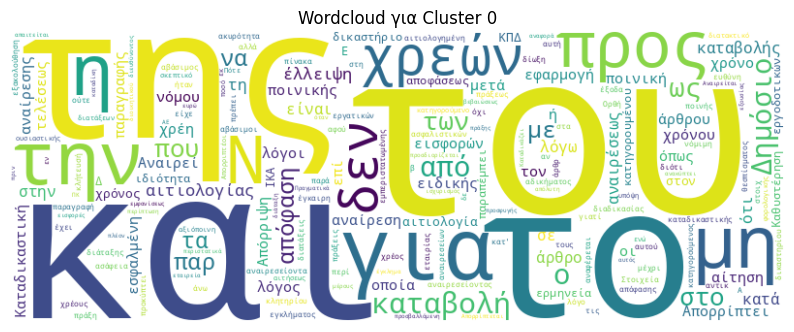

In [35]:
from wordcloud import WordCloud

cluster_id = 0  # διάλεξε συστάδα
text = " ".join(df[df['cluster']==cluster_id]['summary'].dropna())
wordcloud = WordCloud(width=800, height=300, background_color='white', collocations=False).generate(text)
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f"Wordcloud για Cluster {cluster_id}")
plt.show()
